# Fourier Features + MLP (variable-length → fixed FFT features)

In [1]:
# =========================
# 0) Imports + config
# =========================
from pathlib import Path
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix

rng = np.random.default_rng(42)
base_dir = Path("synthetic_timeseries_dataset")
classes = ["normal", "fault_1", "fault_2"]
label_to_int = {c:i for i,c in enumerate(classes)}

fs = 100.0
n_per_class = 100
len_min, len_max = 400, 1200

nfft = 1024
f_lo, f_hi = 0.0, 30.0
freqs = np.fft.rfftfreq(nfft, d=1/fs)
band_bins = np.where((freqs >= f_lo) & (freqs <= f_hi))[0]

for c in classes:
    (base_dir / c).mkdir(parents=True, exist_ok=True)

In [2]:
# =========================
# 1) Synthetic dataset (save .npy)
# =========================
def make_sample(label: str, L: int, fs: float, rng: np.random.Generator) -> np.ndarray:
    t = np.arange(L) / fs

    ch1 = 1.0*np.sin(2*np.pi*5.0*t) + 0.4*np.sin(2*np.pi*12.0*t)
    ch2 = 0.9*np.sin(2*np.pi*3.0*t + 0.4) + 0.3*np.sin(2*np.pi*9.0*t + 1.2)

    if label == "normal":
        x1 = ch1 + 0.20*rng.standard_normal(L)
        x2 = ch2 + 0.20*rng.standard_normal(L)

    elif label == "fault_1":
        x1 = ch1 + 1.2*np.sin(2*np.pi*20.0*t + 0.2) + 0.25*rng.standard_normal(L)
        x2 = ch2 + 0.9*np.sin(2*np.pi*18.0*t + 0.9) + 0.25*rng.standard_normal(L)

    elif label == "fault_2":
        drift  = np.sin(2*np.pi*(6.0 + 2.0*(t/t.max()))*t)
        bursts = np.zeros(L)
        for _ in range(rng.integers(3, 7)):
            center = rng.integers(0, L)
            width  = rng.integers(5, 30)
            amp    = rng.uniform(2.0, 4.0)
            left, right = max(0, center-width), min(L, center+width)
            bursts[left:right] += amp * np.hanning(right-left)
        x1 = ch1 + 0.8*drift + bursts     + 0.25*rng.standard_normal(L)
        x2 = ch2 + 0.6*drift + 0.7*bursts + 0.25*rng.standard_normal(L)

    else:
        raise ValueError("Unknown label")

    return np.stack([x1, x2], axis=1).astype(np.float32)

for label in classes:
    for i in range(n_per_class):
        L = int(rng.integers(len_min, len_max + 1))
        np.save(base_dir / label / f"{label}_{i:03d}.npy", make_sample(label, L, fs, rng))

print("Saved to:", base_dir.resolve())
print({c: len(list((base_dir/c).glob("*.npy"))) for c in classes})

Saved to: /content/synthetic_timeseries_dataset
{'normal': 100, 'fault_1': 100, 'fault_2': 100}


In [3]:
# =========================
# 2) Fourier features
# =========================
def zscore_per_channel(x: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    return (x - x.mean(axis=0, keepdims=True)) / (x.std(axis=0, keepdims=True) + eps)

def fourier_features(x: np.ndarray) -> np.ndarray:
    xz  = zscore_per_channel(x)                           # (L,2)
    Xf  = np.fft.rfft(xz, n=nfft, axis=0)                 # (F,2)
    mag = np.abs(Xf)[band_bins, :]                        # (B,2)
    feat = np.log1p(mag).reshape(-1).astype(np.float32)   # (2B,)
    return feat

X, y = [], []
for c in classes:
    for fp in sorted((base_dir / c).glob("*.npy")):
        X.append(fourier_features(np.load(fp)))
        y.append(label_to_int[c])

X = np.stack(X)
y = np.array(y, dtype=int)
print("X:", X.shape, "| y:", np.bincount(y))

X: (300, 616) | y: [100 100 100]


In [4]:
# =========================
# 3) Train MLP
# =========================
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
Xtr = scaler.fit_transform(Xtr)
Xte = scaler.transform(Xte)

clf = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    batch_size=64,
    learning_rate_init=1e-3,
    max_iter=400,
    early_stopping=True,
    n_iter_no_change=15,
    random_state=42,
    verbose=False,
)
clf.fit(Xtr, ytr)

MLPClassifier(batch_size=64, early_stopping=True, hidden_layer_sizes=(64, 32),
              max_iter=400, n_iter_no_change=15, random_state=42)

In [5]:
# =========================
# 4) Reports
# =========================
for name, Xt, yt in [("TRAIN", Xtr, ytr), ("TEST", Xte, yte)]:
    yh = clf.predict(Xt)
    print(f"\n=== {name} report ===")
    print(classification_report(yt, yh, target_names=classes, digits=4))
    print("Confusion:\n", confusion_matrix(yt, yh))

print(f"\nBand {f_lo}-{f_hi} Hz | nfft={nfft} | band_bins={len(band_bins)} | feat_dim={X.shape[1]}")


=== TRAIN report ===
              precision    recall  f1-score   support

      normal     1.0000    0.9875    0.9937        80
     fault_1     0.9877    1.0000    0.9938        80
     fault_2     1.0000    1.0000    1.0000        80

    accuracy                         0.9958       240
   macro avg     0.9959    0.9958    0.9958       240
weighted avg     0.9959    0.9958    0.9958       240

Confusion:
 [[79  1  0]
 [ 0 80  0]
 [ 0  0 80]]

=== TEST report ===
              precision    recall  f1-score   support

      normal     1.0000    1.0000    1.0000        20
     fault_1     1.0000    1.0000    1.0000        20
     fault_2     1.0000    1.0000    1.0000        20

    accuracy                         1.0000        60
   macro avg     1.0000    1.0000    1.0000        60
weighted avg     1.0000    1.0000    1.0000        60

Confusion:
 [[20  0  0]
 [ 0 20  0]
 [ 0  0 20]]

Band 0.0-30.0 Hz | nfft=1024 | band_bins=308 | feat_dim=616


## Quick Time vs Frequency Plots (few per class)

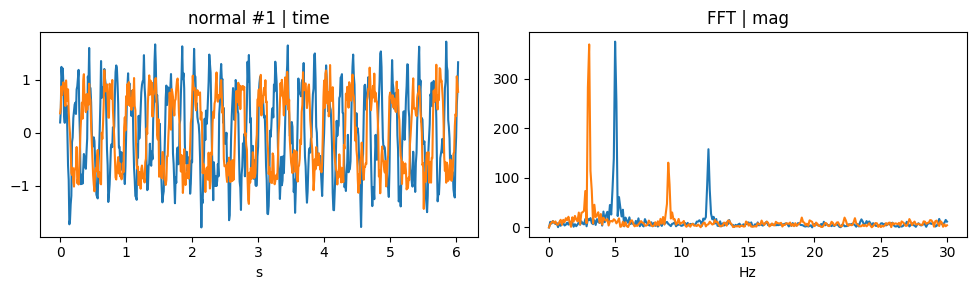

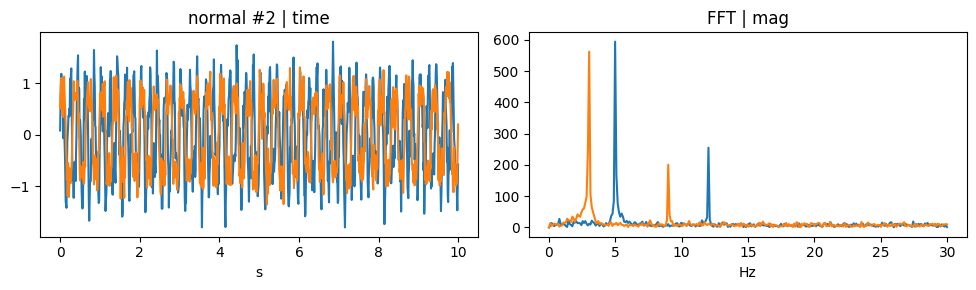

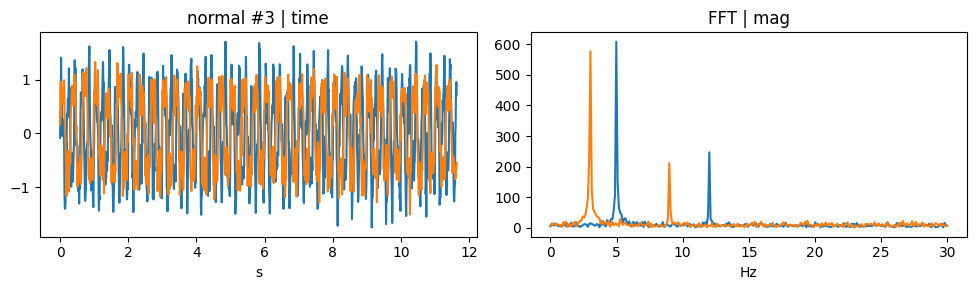

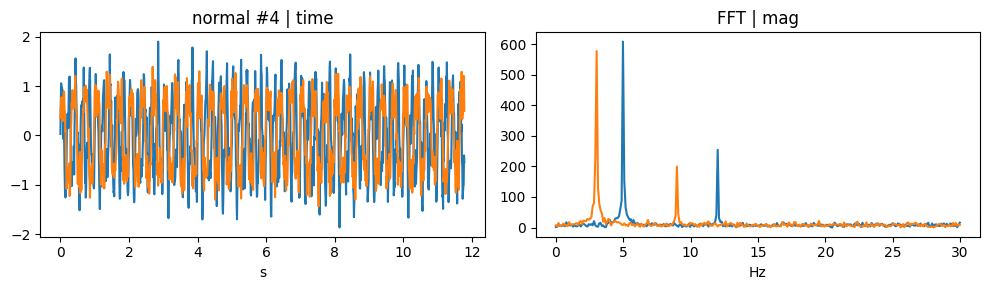

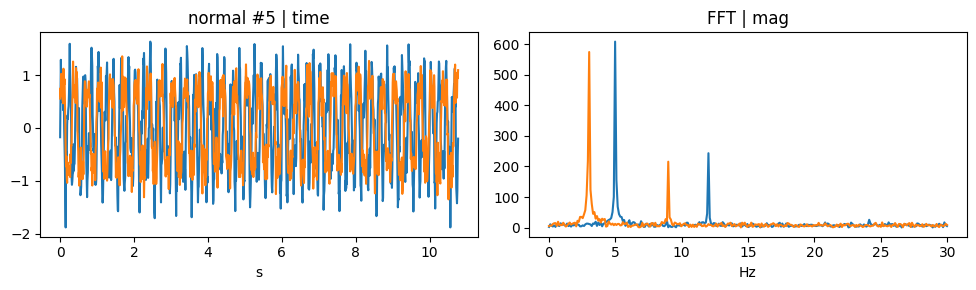

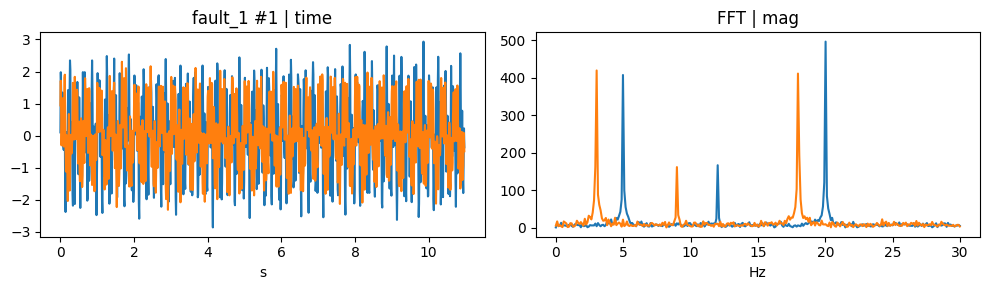

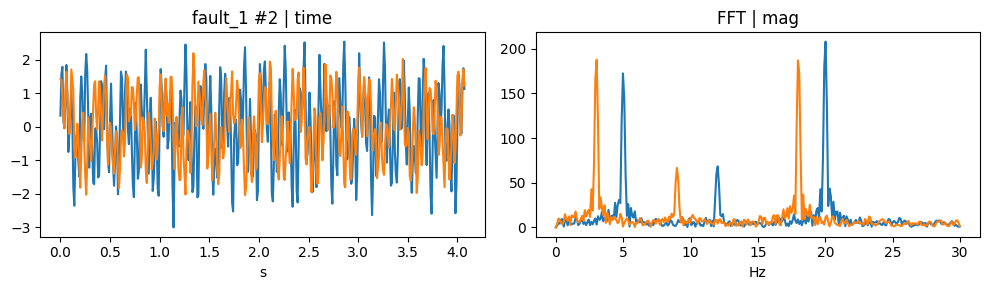

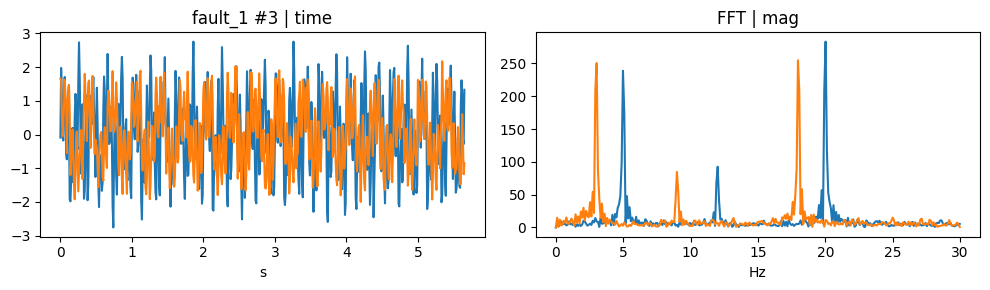

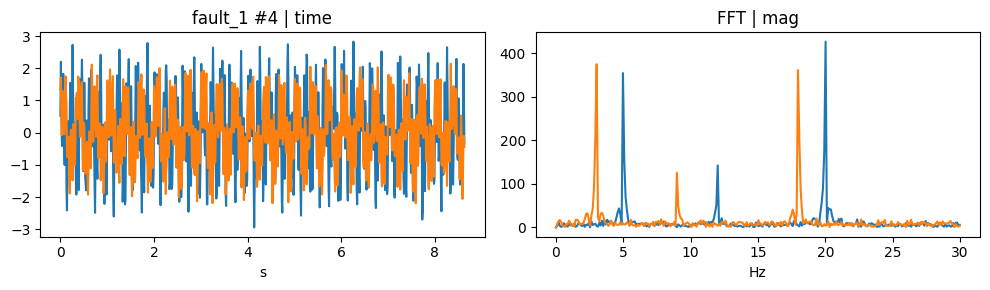

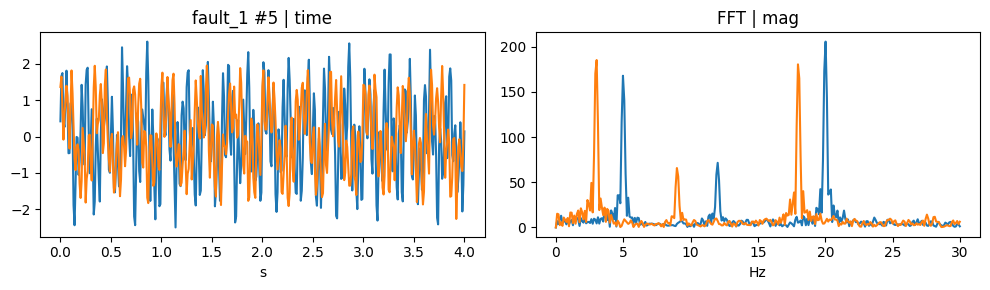

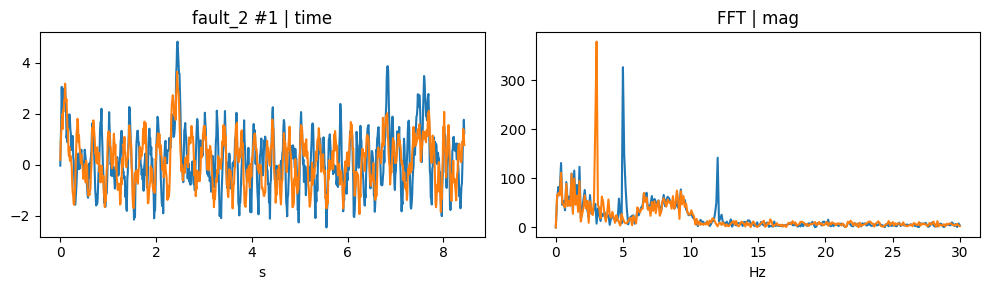

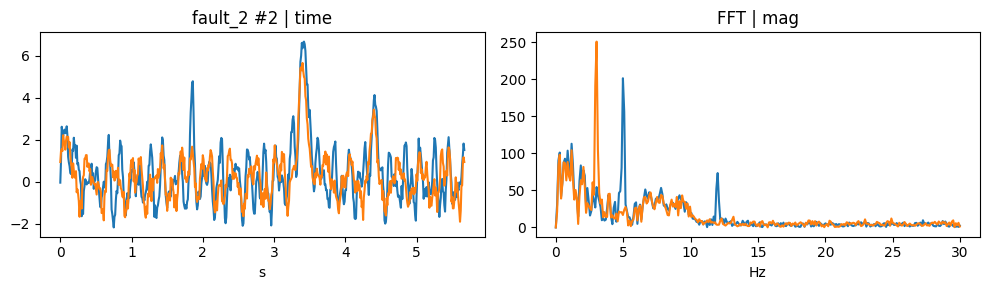

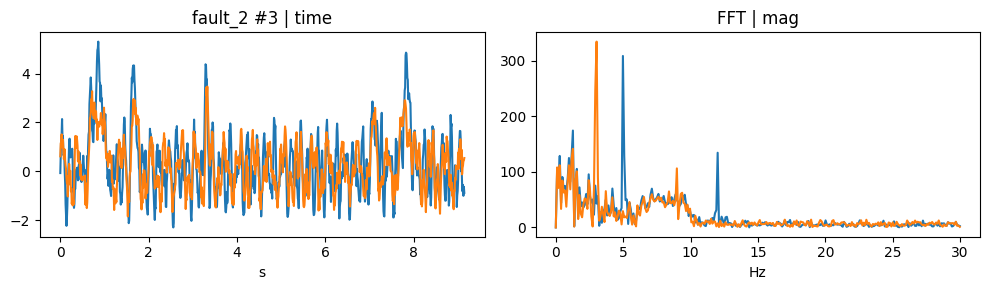

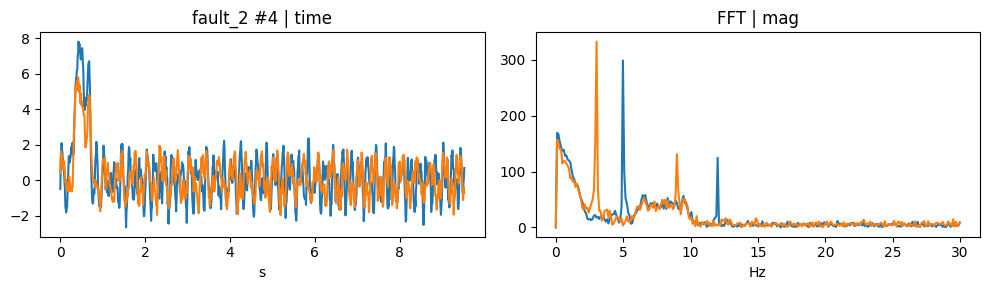

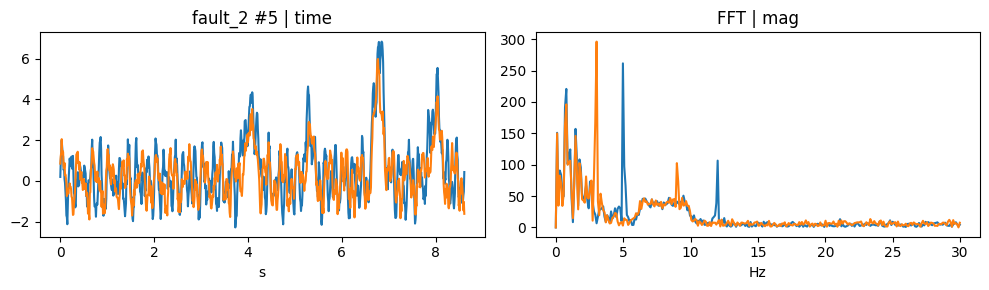

In [6]:
# =========================
# Time vs spectrum (n_show per class)
# =========================
import matplotlib.pyplot as plt

n_show = 5
rng = np.random.default_rng(0)

def band_spectrum(x: np.ndarray):
    xz = zscore_per_channel(x)
    Xf = np.fft.rfft(xz, n=nfft, axis=0)
    mag = np.abs(Xf)[band_bins, :]
    return freqs[band_bins], mag

for cls in classes:
    files = sorted((base_dir / cls).glob("*.npy"))
    pick = rng.choice(files, size=min(n_show, len(files)), replace=False)

    for i, fp in enumerate(pick, 1):
        x = np.load(fp)
        t = np.arange(len(x)) / fs
        f, mag = band_spectrum(x)

        fig, ax = plt.subplots(1, 2, figsize=(10, 3))
        ax[0].plot(t, x[:, 0]); ax[0].plot(t, x[:, 1])
        ax[0].set_title(f"{cls} #{i} | time"); ax[0].set_xlabel("s")

        ax[1].plot(f, mag[:, 0]); ax[1].plot(f, mag[:, 1])
        ax[1].set_title("FFT | mag"); ax[1].set_xlabel("Hz")

        plt.tight_layout()
        plt.show()

# LSTM (variable-length, packed sequences)

In [7]:
# =========================
# 0) Imports + config
# =========================
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

base_dir = Path("synthetic_timeseries_dataset")
classes = ["normal", "fault_1", "fault_2"]
label_to_int = {c:i for i,c in enumerate(classes)}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

batch_size = 256
epochs = 200
lr = 1e-3
hidden_dim = 32
num_layers = 2

Device: cuda


In [8]:
# =========================
# 1) File list + split
# =========================
paths, labels = [], []
for c in classes:
    for fp in sorted((base_dir / c).glob("*.npy")):
        paths.append(fp)
        labels.append(label_to_int[c])
paths = np.array(paths)
labels = np.array(labels, dtype=int)

tr_idx, te_idx = train_test_split(np.arange(len(paths)), test_size=0.2, random_state=42, stratify=labels)

In [9]:
# =========================
# 2) Dataset + collate (pad + lengths)
# =========================
def zscore_per_channel(x, eps=1e-8):
    return (x - x.mean(axis=0, keepdims=True)) / (x.std(axis=0, keepdims=True) + eps)

class VarLenNPYDataset(Dataset):
    def __init__(self, paths, labels):
        self.paths = list(paths)
        self.labels = labels.astype(int)

    def __len__(self): return len(self.paths)

    def __getitem__(self, i):
        x = zscore_per_channel(np.load(self.paths[i])).astype(np.float32)  # (L,2)
        return torch.from_numpy(x), int(self.labels[i])

def collate_pad(batch):
    xs, ys = zip(*batch)
    lengths = torch.tensor([x.shape[0] for x in xs], dtype=torch.long)
    maxL = int(lengths.max())
    Xpad = torch.zeros(len(xs), maxL, xs[0].shape[1], dtype=torch.float32)
    for i, x in enumerate(xs):
        Xpad[i, :x.shape[0]] = x
    return Xpad, lengths, torch.tensor(ys, dtype=torch.long)

train_loader = DataLoader(VarLenNPYDataset(paths[tr_idx], labels[tr_idx]),
                          batch_size=batch_size, shuffle=True, collate_fn=collate_pad,
                          pin_memory=(device.type=="cuda"))
test_loader  = DataLoader(VarLenNPYDataset(paths[te_idx], labels[te_idx]),
                          batch_size=batch_size, shuffle=False, collate_fn=collate_pad,
                          pin_memory=(device.type=="cuda"))

In [10]:
# =========================
# 3) Model
# =========================
class LSTMClassifier(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=32, num_layers=2, n_classes=3, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=num_layers, batch_first=True,
                            dropout=(dropout if num_layers > 1 else 0.0))
        self.fc = nn.Linear(hidden_dim, n_classes)

    def forward(self, x, lengths):
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (h_n, _) = self.lstm(packed)
        return self.fc(h_n[-1])  # last layer hidden: (B,H)

model = LSTMClassifier(hidden_dim=hidden_dim, num_layers=num_layers, n_classes=len(classes)).to(device)
opt = torch.optim.Adam(model.parameters(), lr=lr)
loss_fn = nn.CrossEntropyLoss()

In [11]:
# =========================
# 4) Train + eval
# =========================
for ep in range(1, epochs+1):
    model.train()
    tot, n = 0.0, 0
    for Xpad, lengths, y in train_loader:
        Xpad, lengths, y = Xpad.to(device), lengths.to(device), y.to(device)
        logits = model(Xpad, lengths)
        loss = loss_fn(logits, y)
        opt.zero_grad(); loss.backward(); opt.step()
        tot += loss.item() * y.size(0); n += y.size(0)
    print(f"Epoch {ep:03d}/{epochs} | train CE = {tot/n:.4f}")

@torch.no_grad()
def predict(loader):
    model.eval()
    ys, yh = [], []
    for Xpad, lengths, y in loader:
        logits = model(Xpad.to(device), lengths.to(device))
        yh.append(logits.argmax(1).cpu().numpy())
        ys.append(y.numpy())
    return np.concatenate(ys), np.concatenate(yh)

ytr, ytr_hat = predict(train_loader)
yte, yte_hat = predict(test_loader)

print("\n=== LSTM TRAIN ===")
print(classification_report(ytr, ytr_hat, target_names=classes, digits=4))
print("Confusion:\n", confusion_matrix(ytr, ytr_hat))

print("\n=== LSTM TEST ===")
print(classification_report(yte, yte_hat, target_names=classes, digits=4))
print("Confusion:\n", confusion_matrix(yte, yte_hat))

Epoch 001/200 | train CE = 1.1043
Epoch 002/200 | train CE = 1.1033
Epoch 003/200 | train CE = 1.1024
Epoch 004/200 | train CE = 1.1018
Epoch 005/200 | train CE = 1.1007
Epoch 006/200 | train CE = 1.0998
Epoch 007/200 | train CE = 1.0990
Epoch 008/200 | train CE = 1.0983
Epoch 009/200 | train CE = 1.0976
Epoch 010/200 | train CE = 1.0969
Epoch 011/200 | train CE = 1.0961
Epoch 012/200 | train CE = 1.0955
Epoch 013/200 | train CE = 1.0949
Epoch 014/200 | train CE = 1.0944
Epoch 015/200 | train CE = 1.0938
Epoch 016/200 | train CE = 1.0935
Epoch 017/200 | train CE = 1.0927
Epoch 018/200 | train CE = 1.0919
Epoch 019/200 | train CE = 1.0914
Epoch 020/200 | train CE = 1.0906
Epoch 021/200 | train CE = 1.0900
Epoch 022/200 | train CE = 1.0892
Epoch 023/200 | train CE = 1.0882
Epoch 024/200 | train CE = 1.0877
Epoch 025/200 | train CE = 1.0860
Epoch 026/200 | train CE = 1.0855
Epoch 027/200 | train CE = 1.0839
Epoch 028/200 | train CE = 1.0823
Epoch 029/200 | train CE = 1.0805
Epoch 030/200 

# 1D CNN (fixed length pad/truncate + global average pool)

In [12]:
# =========================
# 0) Imports + config
# =========================
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

base_dir = Path("synthetic_timeseries_dataset")
classes = ["normal", "fault_1", "fault_2"]
label_to_int = {c:i for i,c in enumerate(classes)}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

fixed_L = 1024
batch_size = 64
epochs = 15
lr = 1e-3

Device: cuda


In [13]:
# =========================
# 1) File list + split
# =========================
paths, labels = [], []
for c in classes:
    for fp in sorted((base_dir / c).glob("*.npy")):
        paths.append(fp)
        labels.append(label_to_int[c])
paths = np.array(paths)
labels = np.array(labels, dtype=int)

tr_idx, te_idx = train_test_split(np.arange(len(paths)), test_size=0.2, random_state=42, stratify=labels)

In [14]:
# =========================
# 2) Dataset (pad/truncate) -> (C,L)
# =========================
def zscore_per_channel(x, eps=1e-8):
    return (x - x.mean(axis=0, keepdims=True)) / (x.std(axis=0, keepdims=True) + eps)

class FixedLenNPYDataset(Dataset):
    def __init__(self, paths, labels, fixed_L=1024):
        self.paths = list(paths)
        self.labels = labels.astype(int)
        self.fixed_L = fixed_L

    def __len__(self): return len(self.paths)

    def __getitem__(self, i):
        x = zscore_per_channel(np.load(self.paths[i])).astype(np.float32)  # (L,2)
        L = x.shape[0]
        if L >= self.fixed_L:
            x = x[:self.fixed_L]
        else:
            x = np.vstack([x, np.zeros((self.fixed_L - L, 2), dtype=np.float32)])
        x = x.T  # (2, fixed_L)
        return torch.from_numpy(x), int(self.labels[i])

train_loader = DataLoader(FixedLenNPYDataset(paths[tr_idx], labels[tr_idx], fixed_L),
                          batch_size=batch_size, shuffle=True, pin_memory=(device.type=="cuda"))
test_loader  = DataLoader(FixedLenNPYDataset(paths[te_idx], labels[te_idx], fixed_L),
                          batch_size=batch_size, shuffle=False, pin_memory=(device.type=="cuda"))

In [15]:
# =========================
# 3) Model (Conv1d + AdaptiveAvgPool1d)
# =========================
class CNN1D(nn.Module):
    def __init__(self, in_ch=2, n_classes=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_ch, 16, 7, padding=3), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(16, 32, 5, padding=2),   nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(32, 64, 3, padding=1),   nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),           # global avg pool over time -> (B,64,1)
            nn.Flatten(),                      # -> (B,64)
            nn.Linear(64, n_classes)
        )

    def forward(self, x):  # x: (B,C,L)
        return self.net(x)

model = CNN1D(in_ch=2, n_classes=len(classes)).to(device)
opt = torch.optim.Adam(model.parameters(), lr=lr)
loss_fn = nn.CrossEntropyLoss()

In [16]:
# =========================
# 4) Train + eval
# =========================
for ep in range(1, epochs+1):
    model.train()
    tot, n = 0.0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = loss_fn(logits, yb)
        opt.zero_grad(); loss.backward(); opt.step()
        tot += loss.item() * yb.size(0); n += yb.size(0)
    print(f"Epoch {ep:02d}/{epochs} | train CE = {tot/n:.4f}")

@torch.no_grad()
def predict(loader):
    model.eval()
    ys, yh = [], []
    for xb, yb in loader:
        pred = model(xb.to(device)).argmax(1).cpu().numpy()
        yh.append(pred); ys.append(yb.numpy())
    return np.concatenate(ys), np.concatenate(yh)

ytr, ytr_hat = predict(train_loader)
yte, yte_hat = predict(test_loader)

print("\n=== CNN TRAIN ===")
print(classification_report(ytr, ytr_hat, target_names=classes, digits=4))
print("Confusion:\n", confusion_matrix(ytr, ytr_hat))

print("\n=== CNN TEST ===")
print(classification_report(yte, yte_hat, target_names=classes, digits=4))
print("Confusion:\n", confusion_matrix(yte, yte_hat))

Epoch 01/15 | train CE = 1.0963
Epoch 02/15 | train CE = 1.0766
Epoch 03/15 | train CE = 1.0617
Epoch 04/15 | train CE = 1.0375
Epoch 05/15 | train CE = 1.0030
Epoch 06/15 | train CE = 0.9549
Epoch 07/15 | train CE = 0.8887
Epoch 08/15 | train CE = 0.8046
Epoch 09/15 | train CE = 0.7119
Epoch 10/15 | train CE = 0.6200
Epoch 11/15 | train CE = 0.5478
Epoch 12/15 | train CE = 0.4872
Epoch 13/15 | train CE = 0.4429
Epoch 14/15 | train CE = 0.4074
Epoch 15/15 | train CE = 0.3719

=== CNN TRAIN ===
              precision    recall  f1-score   support

      normal     1.0000    1.0000    1.0000        80
     fault_1     1.0000    1.0000    1.0000        80
     fault_2     1.0000    1.0000    1.0000        80

    accuracy                         1.0000       240
   macro avg     1.0000    1.0000    1.0000       240
weighted avg     1.0000    1.0000    1.0000       240

Confusion:
 [[80  0  0]
 [ 0 80  0]
 [ 0  0 80]]

=== CNN TEST ===
              precision    recall  f1-score   support